# Understanding how attention works 

This notebook is to explore how the different heads learn how to classify flowers and to see what they see in the most intuitive way possible.

### Imports

In [51]:
import os
import torch
import timm
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from torchvision import transforms
from torchvision.datasets import Flowers102

In [52]:
img_save_path = Path("../figures/")

### Devices

In [29]:
device = (
    torch.device("mps") if torch.backends.mps.is_available()
    else torch.device("cuda") if torch.cuda.is_available()
    else torch.device("cpu")
)

print(f"Using device: {device}")

Using device: mps


### Create and import the finetuned the model

In [30]:
model = timm.create_model(
    "vit_base_patch16_224",
    pretrained=False,
    img_size=384,
    num_classes=102,
)

checkpoint = torch.load(
    "finetuned_models/best_model.pth",
    map_location=device,
)

model.load_state_dict(checkpoint["model"])
model.to(device)
model.eval()

print("Loaded the model")

Loaded the model


### Attention rollout

In [48]:
# Predetermined hyperparameters
PATCH_SIZE = 16
IMG_SIZE = 384
GRID = IMG_SIZE // PATCH_SIZE 

In [32]:
#Transformation for the dataset
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

In [ ]:
#Dataset loading
dataset = Flowers102(
    root="archive/flowers102",
    split="test",
    transform=transform,
    download=True,
)

## Reconstructing attention and VIT heads to visualise

For clarification I will add the mathematics behind this as stated in understanding_vit_from_scratch.ipynb

In [33]:
img_tensor, label = dataset[0]
input_tensor = img_tensor.unsqueeze(0).to(device)

print("Input tensor:", input_tensor.shape)

Input tensor: torch.Size([1, 3, 384, 384])


In [34]:
img = transforms.ToPILImage()(img_tensor)

img_np = np.array(img)

In [35]:
class_names = test_data.classes
class_to_idx = {
    class_name: idx
    for idx, class_name in enumerate(class_names)
}

idx_to_class = {idx: class_name for class_name, idx in class_to_idx.items()}

In [55]:
id = 0 

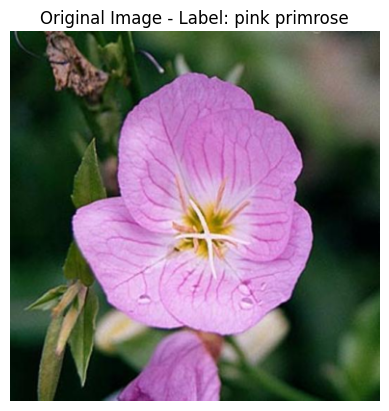

In [57]:
plt.imshow(img_np)
plt.title(f"Original Image - Label: {idx_to_class[label]}")
plt.axis("off")
plt.savefig(img_save_path / f"OxfordFlowers102_{id}_{class_names[label]}.png", dpi=200, bbox_inches="tight")
plt.show()

Starting with the image

$$
X = \mathbb{R}^{B \times C \times H \times W}
$$

$$
P = f_{\text{patch}}(X), \quad P \in \mathbb{R}^{B \times D \times H_p \times W_p}
$$

$B$: batch size, $D$: embedding dim, $H_p = H/p$, $W_p = W/p$, $p$: patch size.

In [37]:
with torch.no_grad():
    patch_embed = model.patch_embed.proj(input_tensor)

print("Patch embedding:", (patch_embed.shape))  

Patch embedding: torch.Size([1, 768, 24, 24])


$$
T = \mathrm{reshape}(P) \in \mathbb{R}^{B \times N \times D}
$$

$N = H_p W_p$: number of patches.

In [38]:
patch_tokens = patch_embed.flatten(2).transpose(1, 2)
print("Patch tokens:", patch_tokens.shape)  # (1, 576, 768)

Patch tokens: torch.Size([1, 576, 768])


$$
Z_0 = [x_{\mathrm{cls}}; T] + E_{\mathrm{pos}} \in \mathbb{R}^{B \times (N+1) \times D}
$$

$x_{\mathrm{cls}}$: class token, $E_{\mathrm{pos}}$: positional embedding.

In [ ]:
cls_token = model.cls_token.expand(input_tensor.shape[0], -1, -1)

transformer_input = torch.cat((cls_token, patch_tokens), dim=1)
transformer_input = transformer_input + model.pos_embed

print("Transformer input:", transformer_input.shape)

Transformer input: torch.Size([1, 577, 768])


$$
(Q,K,V) = W_{\mathrm{qkv}} Z_0
$$

$Q,K,V \in \mathbb{R}^{B \times (N+1) \times D}$, $h$: number of heads, $d = D/h$.

In [40]:

block = model.blocks[0].attn

with torch.no_grad():
    qkv = block.qkv(transformer_input)  # (1, tokens, 3 * dim)

print("Raw QKV:", qkv.shape)

B, N, _ = qkv.shape
dim = model.embed_dim
num_heads = block.num_heads
head_dim = dim // num_heads

Raw QKV: torch.Size([1, 577, 2304])


$$
Q,K \in \mathbb{R}^{B \times h \times (N+1) \times d}
$$

$h$: number of heads, $d$: head dimension.

In [ ]:
qkv = qkv.reshape(B, N, 3, num_heads, head_dim)
q = qkv[:, :, 0].permute(0, 2, 1, 3)  # (B, heads, tokens, head_dim)
k = qkv[:, :, 1].permute(0, 2, 1, 3)

$$
A = QK^\top \in \mathbb{R}^{B \times h \times (N+1) \times (N+1)}
$$

$A$: raw attention scores; $\mathrm{squeeze}(0)$ removes the batch axis.

In [42]:

kT = k.transpose(-2, -1)  # (B, heads, head_dim, tokens)

attention = (q @ kT)  # (B, heads, tokens, tokens)

attention = attention.squeeze(0)  # remove batch

print("Attention:", attention.shape)

Attention: torch.Size([12, 577, 577])


$$
a = A_{:,0,1:N+1} \in \mathbb{R}^{h \times N}
$$

$0$: class token, $1\!:\!N$: patch tokens.

In [43]:
patch_attention = attention[:, 0, 1:]  # (heads, 576)

print("Patch attention:", patch_attention.shape)


Patch attention: torch.Size([12, 576])


$$
a_i \mapsto \mathbb{R}^{H_p \times W_p}, \qquad H_p = W_p = \sqrt{N}
$$

Each head is reshaped to the patch grid for visualisation.

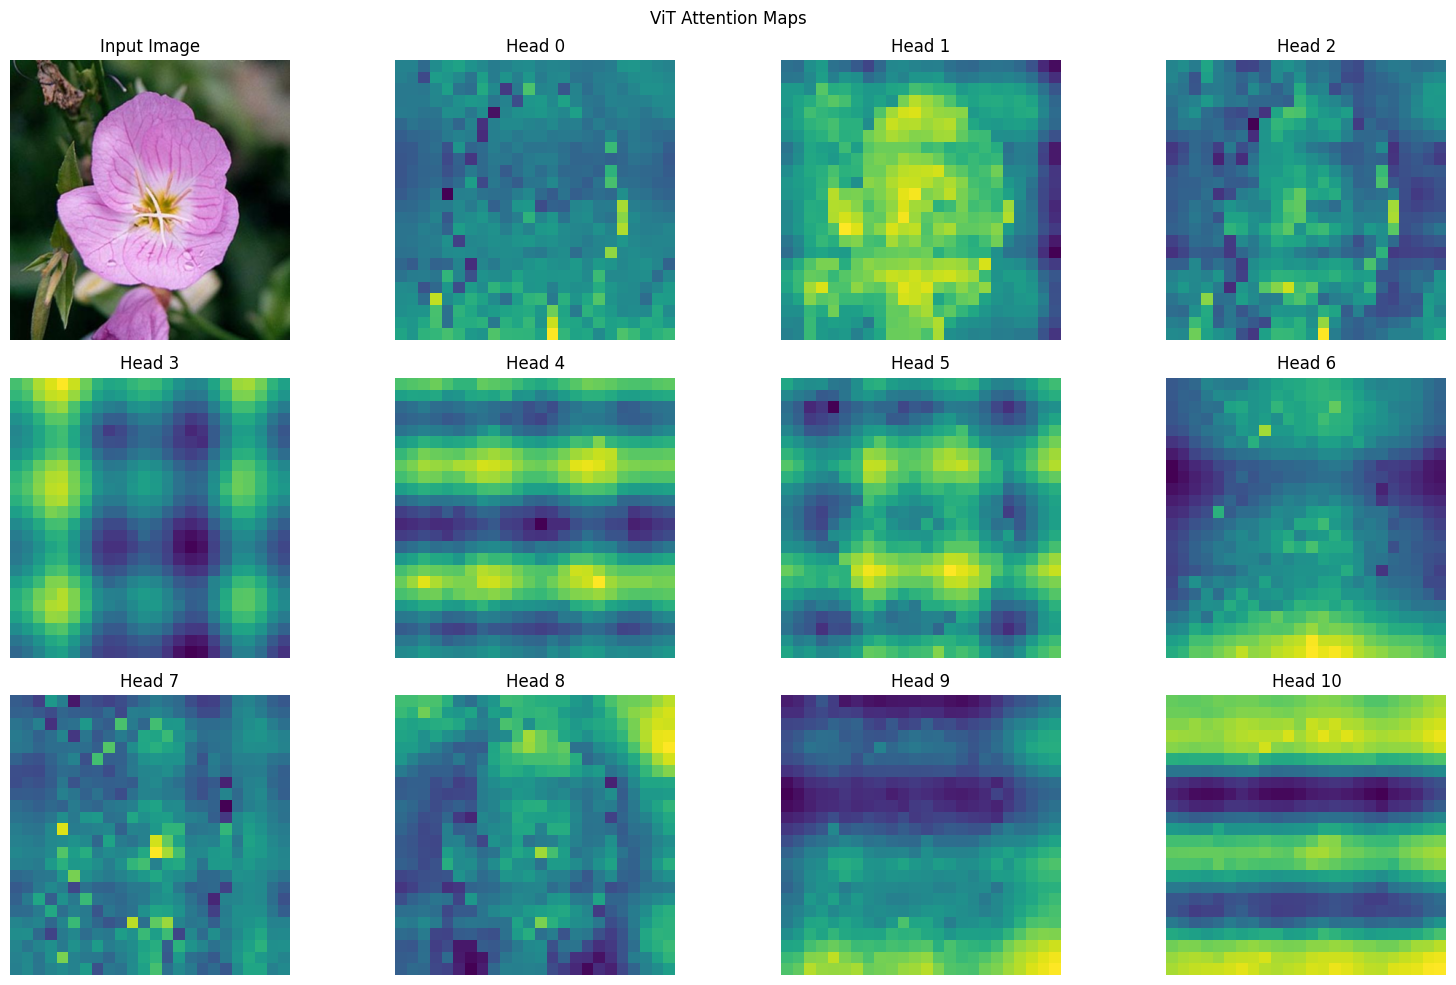

In [ ]:
fig = plt.figure(figsize=(16, 10))
fig.suptitle("ViT Attention Maps")

ax = fig.add_subplot(3, 4, 1)
ax.imshow(img_np)
ax.axis("off")
ax.set_title("Input Image")

# attention heads
for i in range(min(11, num_heads)):
    attn_map = patch_attention[i].reshape(GRID, GRID).cpu().numpy()

    ax = fig.add_subplot(3, 4, i + 2)
    ax.imshow(attn_map, cmap="viridis")
    ax.axis("off")
    ax.set_title(f"Head {i}")


plt.tight_layout()
plt.savefig(f"{img_save_path}/OxfordFlowers102_{id}_{class_name}_multihead_self_attention.png", dpi=200)
plt.show()